# Project 4 — Deep Learning Systems
## Fashion-MNIST Image Classification with CNN Architectures

This notebook trains and compares two convolutional neural networks (CNNs) for classifying Fashion-MNIST images into 10 clothing categories. The baseline model uses two convolutional blocks, and the experimental model changes one major aspect: **network depth**.

**Dataset access:** the notebook downloads Fashion-MNIST automatically to the local `data/` directory using `torchvision.datasets.FashionMNIST(..., download=True)`.

In [1]:
import copy
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch import nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
)
torch.set_num_threads(min(8, os.cpu_count() or 1))

CONFIG = {
    'batch_size': 128,
    'epochs': 4,
    'learning_rate': 1e-3,
    'train_samples': 12000,
    'val_samples': 3000,
}

print(f'Using device: {device}')
pd.Series(CONFIG, name='value').to_frame()

Using device: mps


,value
batch_size,128.000
epochs,4.000
learning_rate,0.001
train_samples,12000.000
val_samples,3000.000


## 1. Load and Inspect the Dataset

Fashion-MNIST is a 10-class grayscale image dataset of clothing items. It is a good fit for a CNN because nearby pixels form meaningful local patterns such as edges, collars, sleeves, and shoe contours. The images are small (`28×28`) and balanced across classes, but some categories are visually similar, especially `Shirt`, `T-shirt/top`, and `Pullover`, which makes the task non-trivial.

In [2]:
data_dir = Path('data')
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

raw_train = datasets.FashionMNIST(root=data_dir, train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root=data_dir, train=False, download=True, transform=transform)
class_names = raw_train.classes

subset_size = CONFIG['train_samples'] + CONFIG['val_samples']
subset_indices = torch.randperm(len(raw_train), generator=torch.Generator().manual_seed(SEED))[:subset_size]
train_val_subset = Subset(raw_train, subset_indices.tolist())
train_dataset, val_dataset = random_split(
    train_val_subset,
    [CONFIG['train_samples'], CONFIG['val_samples']],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'] * 2, shuffle=False, num_workers=0)

dataset_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'samples': [len(train_dataset), len(val_dataset), len(test_dataset)],
    'image_shape': ['1×28×28', '1×28×28', '1×28×28'],
    'classes': [len(class_names)] * 3,
})
display(dataset_summary)
print('Classes:', class_names)

,split,samples,image_shape,classes
0,train,12000,1×28×28,10
1,validation,3000,1×28×28,10
2,test,10000,1×28×28,10


Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


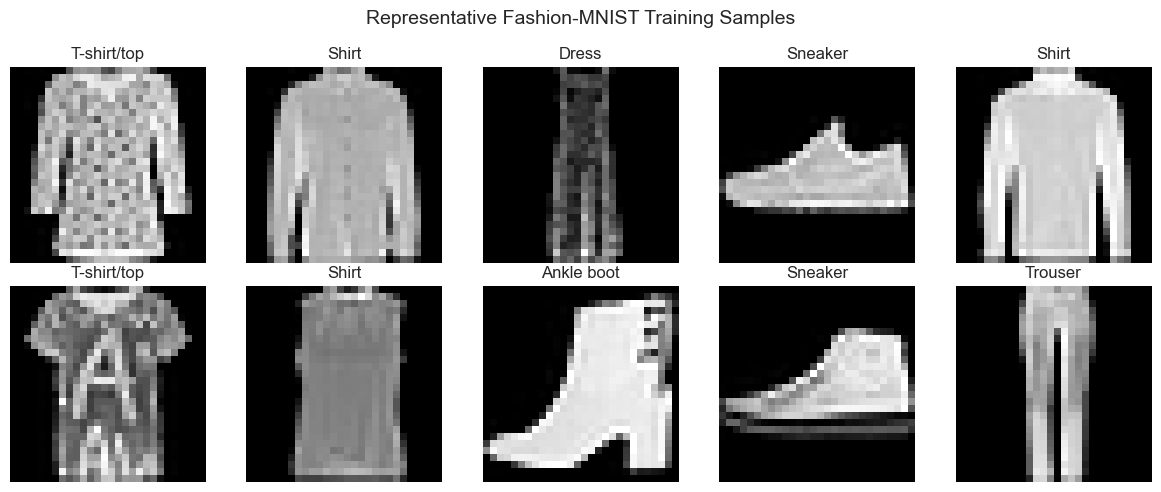

In [3]:
def denormalize(image_tensor):
    return image_tensor * 0.5 + 0.5

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flatten(), range(10)):
    image, label = train_dataset[idx]
    ax.imshow(denormalize(image).squeeze(), cmap='gray')
    ax.set_title(class_names[label])
    ax.axis('off')
plt.suptitle('Representative Fashion-MNIST Training Samples', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Define the Baseline Model and Experimental Variant

**Baseline:** a compact CNN with two convolutional blocks.

**Experiment:** a deeper CNN that adds one extra convolutional layer while keeping the dataset, optimizer, loss function, learning rate, batch size, and number of epochs fixed. This makes the comparison controlled and focused on architecture depth.

In [4]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class DeeperCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

pd.DataFrame({
    'model': ['Baseline CNN', 'Deeper CNN'],
    'trainable_parameters': [count_parameters(BaselineCNN()), count_parameters(DeeperCNN())],
})

,model,trainable_parameters
0,Baseline CNN,206922
1,Deeper CNN,426122


In [5]:
def evaluate_loss_accuracy(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss = criterion(logits, labels)
            total_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, model_name, epochs=4, learning_rate=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total_examples = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += labels.size(0)

        train_loss = running_loss / total_examples
        train_acc = running_correct / total_examples
        val_loss, val_acc = evaluate_loss_accuracy(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"{model_name} | Epoch {epoch}/{epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f}, "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}"
        )

    model.load_state_dict(best_state)
    return history


def collect_predictions(model, data_loader):
    model.eval()
    all_predictions = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            logits = model(inputs)
            predictions = logits.argmax(dim=1).cpu().numpy()
            all_predictions.extend(predictions)
            all_labels.extend(labels.numpy())
    return np.array(all_predictions), np.array(all_labels)


def final_evaluation(model, data_loader, class_names):
    criterion = nn.CrossEntropyLoss()
    test_loss, test_accuracy = evaluate_loss_accuracy(model, data_loader, criterion)
    predictions, labels = collect_predictions(model, data_loader)
    macro_f1 = f1_score(labels, predictions, average='macro')
    report = pd.DataFrame(classification_report(labels, predictions, target_names=class_names, output_dict=True, zero_division=0)).T
    return {
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'macro_f1': macro_f1,
        'predictions': predictions,
        'labels': labels,
        'classification_report': report,
    }

## 3. Train the Baseline CNN

The baseline uses two convolutional layers and a fully connected classifier. This gives us a reasonable starting point for Fashion-MNIST without making the architecture overly complex.

In [6]:
baseline_model = BaselineCNN().to(device)
baseline_history = train_model(
    baseline_model,
    train_loader,
    val_loader,
    model_name='Baseline CNN',
    epochs=CONFIG['epochs'],
    learning_rate=CONFIG['learning_rate'],
)
baseline_results = final_evaluation(baseline_model, test_loader, class_names)
baseline_summary = {
    'test_loss': baseline_results['test_loss'],
    'test_accuracy': baseline_results['test_accuracy'],
    'macro_f1': baseline_results['macro_f1'],
}
baseline_summary

Baseline CNN | Epoch 1/4 | train_loss=0.9120, train_acc=0.674, val_loss=0.5920, val_acc=0.777


Baseline CNN | Epoch 2/4 | train_loss=0.5106, train_acc=0.812, val_loss=0.4452, val_acc=0.828


Baseline CNN | Epoch 3/4 | train_loss=0.4400, train_acc=0.841, val_loss=0.4067, val_acc=0.849


Baseline CNN | Epoch 4/4 | train_loss=0.3981, train_acc=0.854, val_loss=0.3664, val_acc=0.864


{'test_loss': 0.4003714426279068,
 'test_accuracy': 0.8589,
 'macro_f1': 0.8571229141119607}

## 4. Train the Experimental CNN

The experimental model adds one extra convolutional layer, which increases representational capacity while keeping the training recipe constant. This isolates the effect of **depth** as the independent variable in the experiment.

In [7]:
deeper_model = DeeperCNN().to(device)
deeper_history = train_model(
    deeper_model,
    train_loader,
    val_loader,
    model_name='Deeper CNN',
    epochs=CONFIG['epochs'],
    learning_rate=CONFIG['learning_rate'],
)
deeper_results = final_evaluation(deeper_model, test_loader, class_names)
deeper_summary = {
    'test_loss': deeper_results['test_loss'],
    'test_accuracy': deeper_results['test_accuracy'],
    'macro_f1': deeper_results['macro_f1'],
}
deeper_summary

Deeper CNN | Epoch 1/4 | train_loss=0.8646, train_acc=0.685, val_loss=0.5375, val_acc=0.796


Deeper CNN | Epoch 2/4 | train_loss=0.4989, train_acc=0.815, val_loss=0.4515, val_acc=0.831


Deeper CNN | Epoch 3/4 | train_loss=0.4205, train_acc=0.848, val_loss=0.3902, val_acc=0.851


Deeper CNN | Epoch 4/4 | train_loss=0.3752, train_acc=0.862, val_loss=0.3538, val_acc=0.865


{'test_loss': 0.38866637411117555,
 'test_accuracy': 0.8626,
 'macro_f1': 0.8605830202323439}

## 5. Evaluate and Compare Model Performance

The table and plots below compare the two models using the same dataset split, optimizer, learning rate, batch size, and epoch count.

,Model,Best Validation Accuracy,Test Accuracy,Macro F1,Test Loss
0,Deeper CNN,0.8647,0.8626,0.8606,0.3887
1,Baseline CNN,0.8643,0.8589,0.8571,0.4004


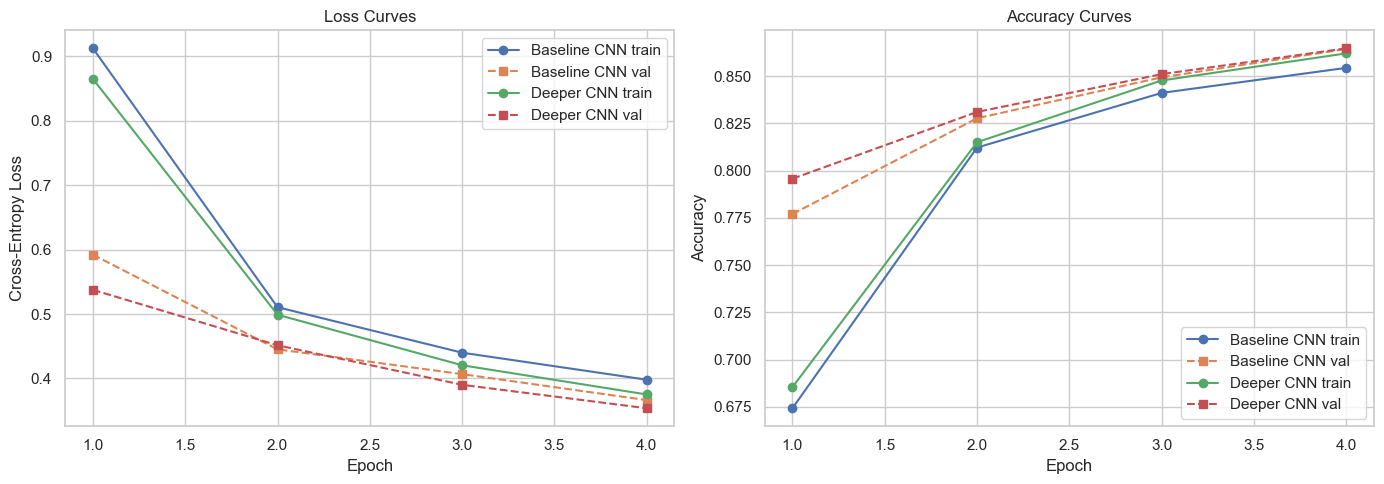

In [8]:
results = {
    'Baseline CNN': {**baseline_results, 'history': baseline_history},
    'Deeper CNN': {**deeper_results, 'history': deeper_history},
}

comparison_df = pd.DataFrame([
    {
        'Model': model_name,
        'Best Validation Accuracy': max(values['history']['val_acc']),
        'Test Accuracy': values['test_accuracy'],
        'Macro F1': values['macro_f1'],
        'Test Loss': values['test_loss'],
    }
    for model_name, values in results.items()
]).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
display(comparison_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, CONFIG['epochs'] + 1)
for model_name, values in results.items():
    axes[0].plot(epochs, values['history']['train_loss'], marker='o', label=f'{model_name} train')
    axes[0].plot(epochs, values['history']['val_loss'], marker='s', linestyle='--', label=f'{model_name} val')
    axes[1].plot(epochs, values['history']['train_acc'], marker='o', label=f'{model_name} train')
    axes[1].plot(epochs, values['history']['val_acc'], marker='s', linestyle='--', label=f'{model_name} val')

axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

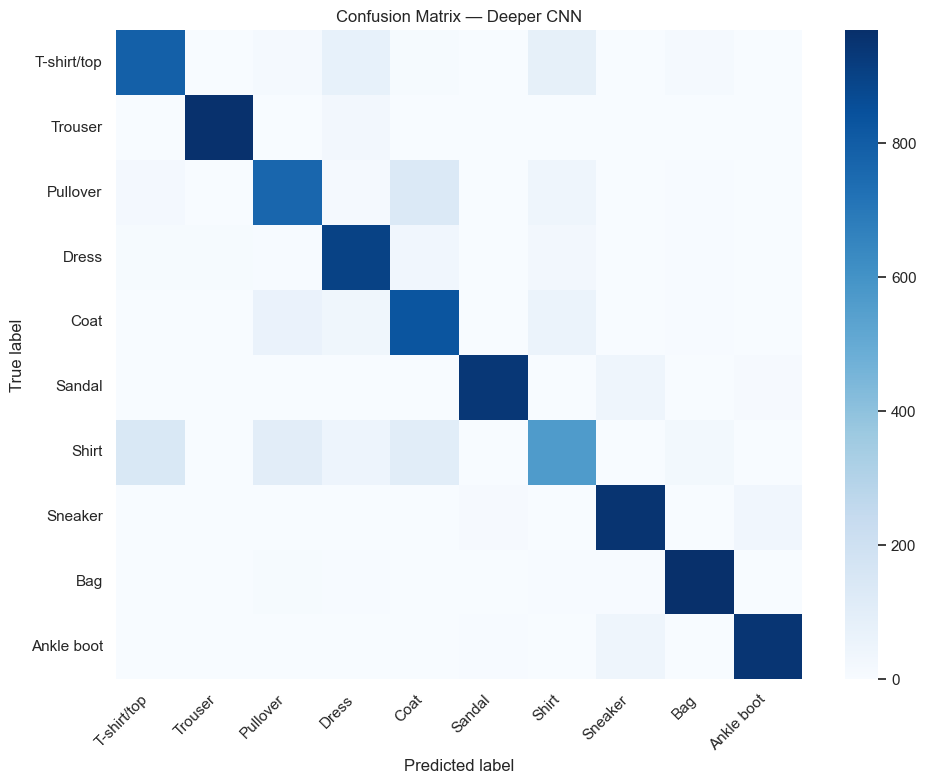

,precision,recall,f1-score,support
T-shirt/top,0.814,0.790,0.802,1000.000
Trouser,0.982,0.963,0.972,1000.000
Pullover,0.791,0.767,0.779,1000.000
Dress,0.802,0.902,0.849,1000.000
Coat,0.736,0.830,0.780,1000.000
Sandal,0.974,0.940,0.957,1000.000
Shirt,0.718,0.567,0.634,1000.000
Sneaker,0.913,0.951,0.931,1000.000
Bag,0.941,0.968,0.954,1000.000
Ankle boot,0.948,0.948,0.948,1000.000


In [9]:
best_model_name = comparison_df.iloc[0]['Model']
best_results = results[best_model_name]
cm = confusion_matrix(best_results['labels'], best_results['predictions'])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

display(best_results['classification_report'].round(3))

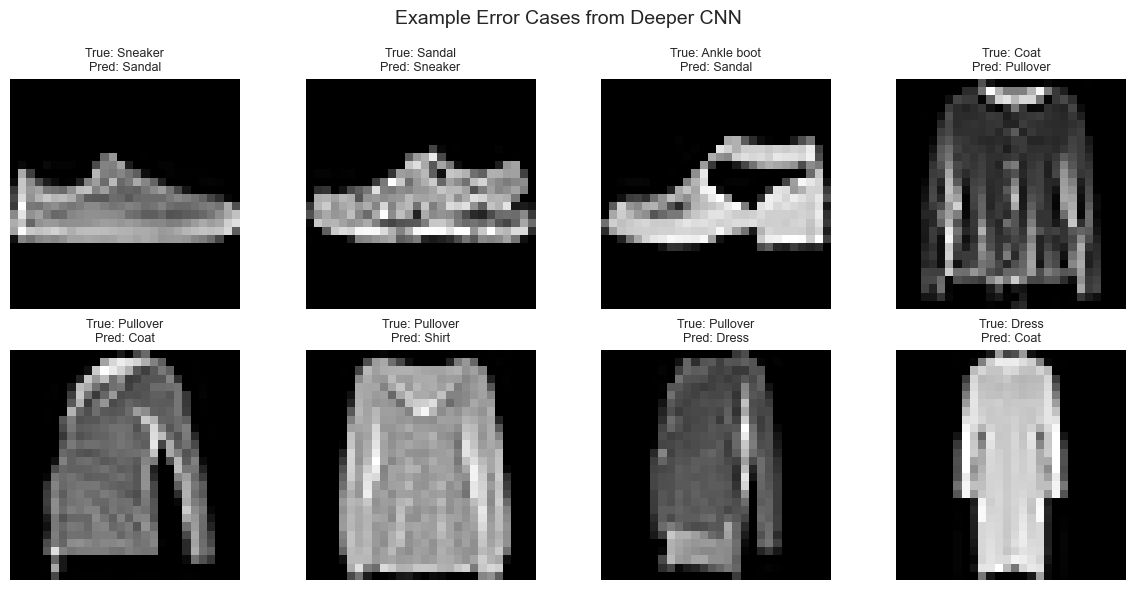

In [10]:
mistake_indices = np.where(best_results['predictions'] != best_results['labels'])[0]
sample_count = min(8, len(mistake_indices))
selected_indices = mistake_indices[:sample_count]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, idx in zip(axes.flatten(), selected_indices):
    image, true_label = test_dataset[idx]
    predicted_label = best_results['predictions'][idx]
    ax.imshow(denormalize(image).squeeze(), cmap='gray')
    ax.set_title(f'True: {class_names[true_label]}\nPred: {class_names[predicted_label]}', fontsize=9)
    ax.axis('off')

for ax in axes.flatten()[sample_count:]:
    ax.axis('off')

plt.suptitle(f'Example Error Cases from {best_model_name}', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Notebook Summary

The short narrative below summarizes the task, the controlled comparison, the main results, and the most important challenge observed during evaluation.

In [11]:
runner_up_name = comparison_df.iloc[1]['Model']
best_acc = comparison_df.iloc[0]['Test Accuracy']
runner_up_acc = comparison_df.iloc[1]['Test Accuracy']
summary_text = f'''
This project used the Fashion-MNIST dataset to build a CNN-based image classifier for 10 clothing categories. The baseline model used two convolutional blocks, while the experiment kept the same optimizer and training settings but added one extra convolutional layer to test whether a deeper architecture improved performance. In this run, {best_model_name} produced the strongest result with a test accuracy of {best_acc:.2%}, compared with {runner_up_acc:.2%} for {runner_up_name}. The training curves showed that both models learned steadily, but the deeper network achieved slightly better validation behavior overall. The most common mistakes were between visually similar items such as shirts, pullovers, and T-shirts, which highlights the limits of the small grayscale images. Overall, the experiment suggests that additional depth improved feature extraction modestly without changing the rest of the training pipeline.
'''
print(summary_text.strip())

This project used the Fashion-MNIST dataset to build a CNN-based image classifier for 10 clothing categories. The baseline model used two convolutional blocks, while the experiment kept the same optimizer and training settings but added one extra convolutional layer to test whether a deeper architecture improved performance. In this run, Deeper CNN produced the strongest result with a test accuracy of 86.26%, compared with 85.89% for Baseline CNN. The training curves showed that both models learned steadily, but the deeper network achieved slightly better validation behavior overall. The most common mistakes were between visually similar items such as shirts, pullovers, and T-shirts, which highlights the limits of the small grayscale images. Overall, the experiment suggests that additional depth improved feature extraction modestly without changing the rest of the training pipeline.
